FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/green_fields.png'

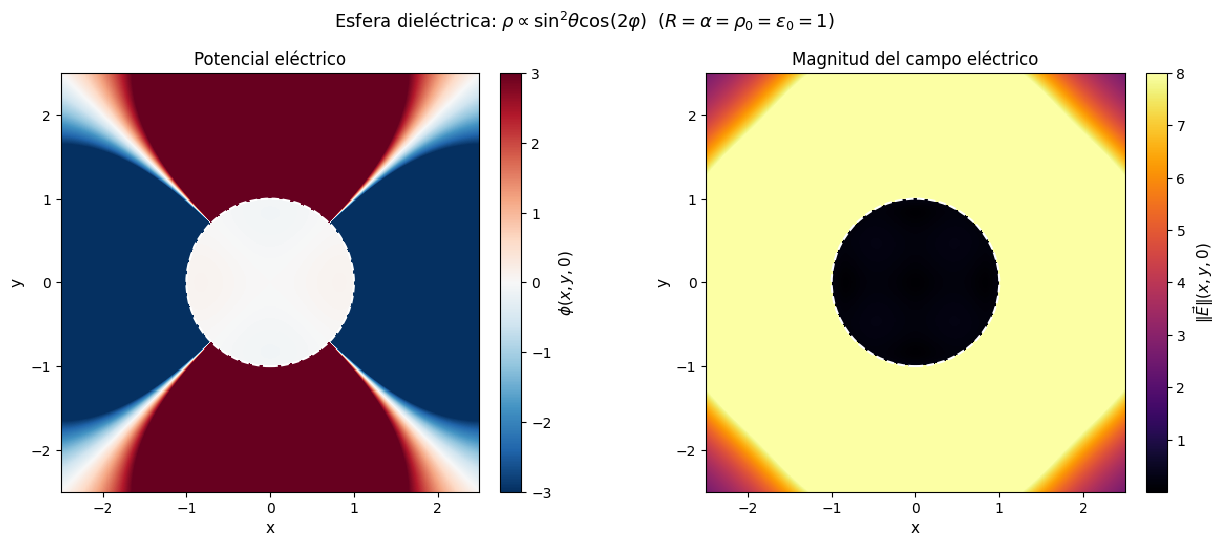

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Circle

# --- Parámetros adimensionales ---
R = 1.0
alpha = 1.0
rho0 = 1.0
eps0 = 1.0

# --- Integrales radiales ---
def I1(r):
    """Integral de 0 a r de r'^5 * exp(alpha*r'/R) dr'"""
    a = alpha / R
    ar = a * r
    ear = np.exp(ar)
    # Integración por partes sucesivas
    poly = (r**5/a - 5*r**4/a**2 + 20*r**3/a**3
            - 60*r**2/a**4 + 120*r/a**5 - 120/a**6)
    return ear * poly + 120/a**6

def I2(r):
    """Integral de r a R de exp(alpha*r'/R) dr'"""
    a = alpha / R
    return (R/alpha) * (np.exp(alpha) - np.exp(a*r))

def f(r):
    return (rho0 / (5*eps0*R)) * (I1(r)/r**3 + r**2 * I2(r))

def df(r):
    return (rho0 / (5*eps0*R)) * (-3*I1(r)/r**4 + 2*r*I2(r))

# --- Factor Q para el exterior ---
a6 = alpha**6
Q = (rho0 * R**5 / (5*eps0*a6)) * (
    np.exp(alpha)*(alpha**5 - 5*alpha**4 + 20*alpha**3
                   - 60*alpha**2 + 120*alpha - 720) + 720
)

# --- Malla en el plano xy (theta = pi/2) ---
N = 400
lim = 2.5
x = np.linspace(-lim, lim, N)
y = np.linspace(-lim, lim, N)
X, Y = np.meshgrid(x, y)

r_xy = np.sqrt(X**2 + Y**2)
phi_xy = np.arctan2(Y, X)      # ángulo azimutal phi
theta_xy = np.pi/2             # plano ecuatorial

sin2th = np.sin(theta_xy)**2   # = 1
sin2th_arr = np.ones_like(r_xy)
cos2phi = np.cos(2*phi_xy)
sin2th_cos2phi = sin2th_arr * cos2phi

# --- Potencial ---
PHI = np.zeros_like(r_xy)
E_mag = np.zeros_like(r_xy)

# Máscara interior / exterior (evitar r=0)
eps_r = 1e-6
r_safe = np.where(r_xy < eps_r, eps_r, r_xy)

interior = r_xy <= R
exterior = ~interior

# Interior
ri = r_safe[interior]
fi = f(ri)
dfi = df(ri)
cos2p_i = cos2phi[interior]
sin2p_i = np.sin(2*phi_xy[interior])
# theta = pi/2 => sin(2theta)=0, sin(theta)=1
PHI[interior] = fi * sin2th_arr[interior] * cos2p_i
Er_i  = -dfi * sin2th_arr[interior] * cos2p_i
Et_i  = 0.0   # -f/r * sin(2*pi/2) = 0
Ep_i  = 2*fi/ri * 1.0 * sin2p_i   # sin(theta)=1
E_mag[interior] = np.sqrt(Er_i**2 + Et_i**2 + Ep_i**2)

# Exterior
re = r_safe[exterior]
cos2p_e = cos2phi[exterior]
sin2p_e = np.sin(2*phi_xy[exterior])
PHI[exterior] = (Q / re**3) * cos2p_e
Er_e  = 3*Q/re**4 * cos2p_e
Et_e  = -Q/re**4 * 0.0   # sin(2*pi/2)=0
Ep_e  = 2*Q/re**4 * 1.0 * sin2p_e
E_mag[exterior] = np.sqrt(Er_e**2 + Et_e**2 + Ep_e**2)

# Clip para visualización
PHI_plot  = np.clip(PHI,  -3, 3)
Emag_plot = np.clip(E_mag, 0, 8)

# --- Figura ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle(r'Esfera dieléctrica: $\rho\propto\sin^2\!\theta\cos(2\varphi)$  '
             r'$(R=\alpha=\rho_0=\epsilon_0=1)$', fontsize=13)

circle_kw = dict(fill=False, color='white', lw=1.5, ls='--')

# --- Panel izquierdo: potencial ---
ax = axes[0]
vmax = np.max(np.abs(PHI_plot))
im = ax.pcolormesh(X, Y, PHI_plot, cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax, shading='auto')
ax.add_patch(Circle((0,0), R, **circle_kw))
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label(r'$\phi(x,y,0)$', fontsize=11)
ax.set_title('Potencial eléctrico', fontsize=12)
ax.set_xlabel('x', fontsize=11); ax.set_ylabel('y', fontsize=11)
ax.set_aspect('equal'); ax.set_xlim(-lim,lim); ax.set_ylim(-lim,lim)

# --- Panel derecho: magnitud del campo ---
ax = axes[1]
im2 = ax.pcolormesh(X, Y, Emag_plot, cmap='inferno', shading='auto')
ax.add_patch(Circle((0,0), R, **circle_kw))
cb2 = fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
cb2.set_label(r'$\|\vec{E}\|(x,y,0)$', fontsize=11)
ax.set_title('Magnitud del campo eléctrico', fontsize=12)
ax.set_xlabel('x', fontsize=11); ax.set_ylabel('y', fontsize=11)
ax.set_aspect('equal'); ax.set_xlim(-lim,lim); ax.set_ylim(-lim,lim)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/green_fields.png', dpi=160, bbox_inches='tight')
print("Guardado.")